![logo_ironhack_blue 7](https://user-images.githubusercontent.com/23629340/40541063-a07a0a8a-601a-11e8-91b5-2f13e4e6b441.png)

---


# **Lab-13: Continuous probability distributions.**


---

### **Alumno:** *Juan Alberto Peñalver Alvarez*


---

# Before your start:

    Read the README.md file
    Comment as much as you can and use the resources (README.md file)
    Happy learning!

In this exercise, we  will generate random numbers from the continuous disributions we learned in the lesson. There are two ways to generate random numbers:

1. Using the numpy library
1. using the Scipy library

Use either or both of the lbraries in this exercise.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math
import seaborn as sns

## Uniform Distribution

To generate uniform random numbers between any two given values using scipy, we can either use the following code or the code that we have
discussed in class:

In [2]:
from scipy.stats import uniform

# Example: generate 10 uniform random numbers between 0 and 1 (default)
sample_01 = uniform.rvs(size=10, random_state=42)

# Example: generate 10 uniform random numbers between `bottom` and `ceiling`
bottom, ceiling, count = 10, 30, 10
sample_10_30 = uniform.rvs(loc=bottom, scale=ceiling-bottom, size=count, random_state=42)

sample_01, sample_10_30


(array([0.37454012, 0.95071431, 0.73199394, 0.59865848, 0.15601864,
        0.15599452, 0.05808361, 0.86617615, 0.60111501, 0.70807258]),
 array([17.49080238, 29.01428613, 24.63987884, 21.97316968, 13.12037281,
        13.11989041, 11.16167224, 27.32352292, 22.02230023, 24.16145156]))

**Your task:**

1. Based on the code above, write a function that generates uniformly distributed random numbers. There are several requirements for your function:
    * It should accept 3 parameters:
        * `bottom` - the lower boundary of the generated numbers
        * `ceiling` - the upper boundary of the generated numbers
        * `count` - how many numbers to generate
    * It should return an array of uniformly distributed random numbers

1. Call your function with 2 sets of params below:
    * bottom=10, ceiling=15, count=100
    * bottom=10, ceiling=60, count=1,000

1. Plot the uniform distributions generated above using histograms, where x axis is the value and y axis is the count. Let the histogram's number of bins be 10.

Your output should look like below:

![uniform distribution](ud.png)

In [3]:
def generate_uniform(bottom: float, ceiling: float, count: int, seed: int | None = None) -> np.ndarray:
    """Generate `count` random numbers uniformly distributed in [bottom, ceiling).

    Parameters
    ----------
    bottom : float
        Lower boundary.
    ceiling : float
        Upper boundary.
    count : int
        Number of samples to generate.
    seed : int | None
        Optional RNG seed for reproducibility.

    Returns
    -------
    np.ndarray
        Array of uniformly distributed random numbers.
    """
    if ceiling <= bottom:
        raise ValueError("`ceiling` must be greater than `bottom`.")
    if count <= 0:
        raise ValueError("`count` must be a positive integer.")

    rng = np.random.default_rng(seed)
    return rng.uniform(low=bottom, high=ceiling, size=count)


In [4]:
u1 = generate_uniform(bottom=0, ceiling=10, count=1000, seed=7)
u2 = generate_uniform(bottom=20, ceiling=50, count=1000, seed=7)

u1[:5], u2[:5]


(array([6.25095467, 8.97213801, 7.7568569 , 2.2520719 , 3.00166285]),
 array([38.752864  , 46.91641403, 43.27057071, 26.7562157 , 29.00498855]))

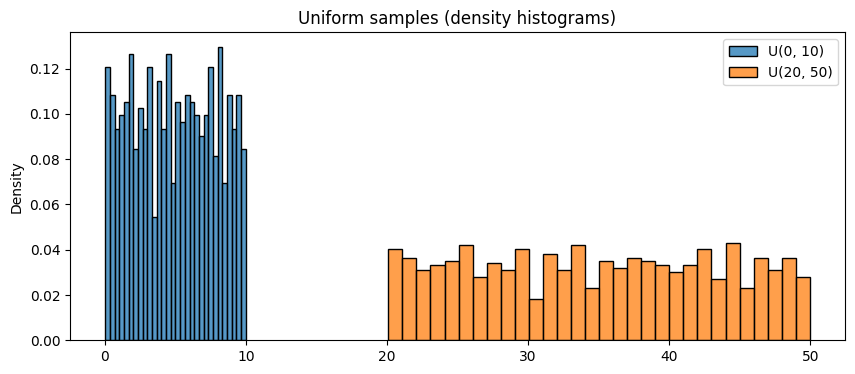

In [5]:
plt.figure(figsize=(10,4))
sns.histplot(u1, bins=30, stat="density", label="U(0, 10)", kde=False)
sns.histplot(u2, bins=30, stat="density", label="U(20, 50)", kde=False)
plt.title("Uniform samples (density histograms)")
plt.legend()
plt.show()


How are the two distributions different?

In [5]:
print(
"""They have the same *shape* (flat / constant density), but different *support* (range) and therefore different centers/spreads.
- U(0, 10) is concentrated between 0 and 10 (mean ≈ 5, smaller spread).
- U(20, 50) is concentrated between 20 and 50 (mean ≈ 35, larger spread)."""
)


They have the same *shape* (flat / constant density), but different *support* (range) and therefore different centers/spreads.
- U(0, 10) is concentrated between 0 and 10 (mean ≈ 5, smaller spread).
- U(20, 50) is concentrated between 20 and 50 (mean ≈ 35, larger spread).


## Normal Distribution

1. In the same way in the Uniform Distribution challenge, write a function that generates normally distributed random numbers.
1. Generate 1,000 normally distributed numbers with the average of 10 and standard deviation of 1
1. Generate 1,000 normally distributed numbers with the average of 10 and standard deviation of 50
2. Plot the distributions of the data generated.

Expected output:

![normal distribution](nd.png)

In [6]:
from scipy.stats import norm

In [7]:
def generate_normal(mean: float, std: float, count: int, seed: int | None = None) -> np.ndarray:
    """Generate `count` random numbers from N(mean, std^2)."""
    if std <= 0:
        raise ValueError("`std` must be positive.")
    if count <= 0:
        raise ValueError("`count` must be a positive integer.")
    rng = np.random.default_rng(seed)
    return rng.normal(loc=mean, scale=std, size=count)


In [8]:
n1 = generate_normal(mean=10, std=1, count=1000, seed=7)
n2 = generate_normal(mean=10, std=50, count=1000, seed=7)

n1[:5], n2[:5]


(array([10.00123015, 10.29874554,  9.72586214,  9.10940816,  9.54532921]),
 array([ 10.06150767,  24.93727688,  -3.70689277, -34.52959194,
        -12.73353926]))

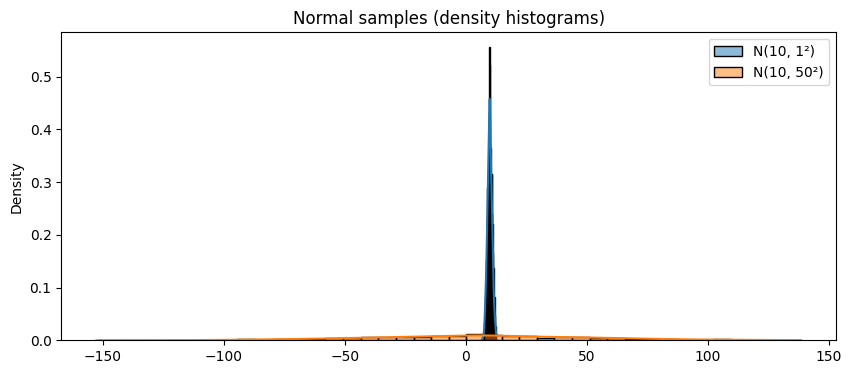

In [9]:
plt.figure(figsize=(10,4))
sns.histplot(n1, bins=40, stat="density", label="N(10, 1²)", kde=True)
sns.histplot(n2, bins=40, stat="density", label="N(10, 50²)", kde=True)
plt.title("Normal samples (density histograms)")
plt.legend()
plt.show()


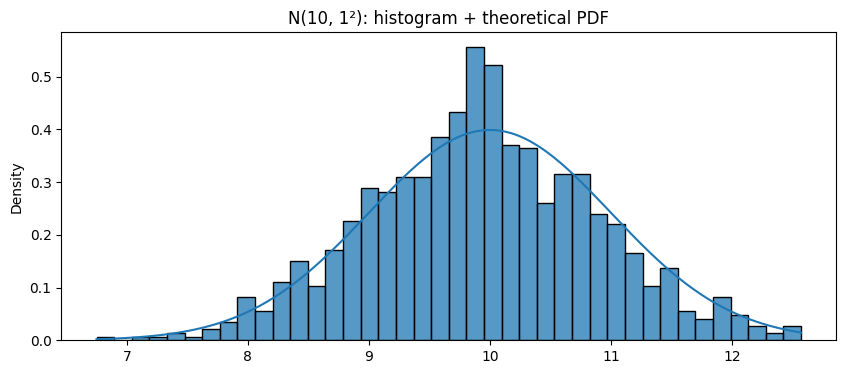

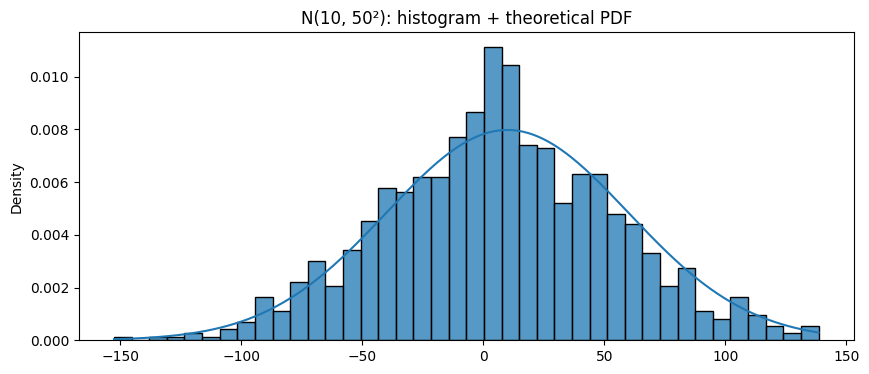

In [10]:
# Overlay theoretical PDFs to highlight the effect of the standard deviation.
x1 = np.linspace(n1.min(), n1.max(), 300)
x2 = np.linspace(n2.min(), n2.max(), 300)

plt.figure(figsize=(10,4))
sns.histplot(n1, bins=40, stat="density", color=None)
plt.plot(x1, norm.pdf(x1, loc=10, scale=1))
plt.title("N(10, 1²): histogram + theoretical PDF")
plt.show()

plt.figure(figsize=(10,4))
sns.histplot(n2, bins=40, stat="density", color=None)
plt.plot(x2, norm.pdf(x2, loc=10, scale=50))
plt.title("N(10, 50²): histogram + theoretical PDF")
plt.show()


How are the two distributions different?

The two distributions have the same mean (10) but very different standard deviations.

- With **std = 1**, values are tightly concentrated around 10 (narrow bell curve).
- With **std = 50**, values are much more spread out (wide bell curve), so extreme values are common.


## Normal Distribution of Real Data

In this challenge we are going to take a look the real data. We will use vehicles.csv file for this exercise

In [12]:
!pwd


/content


In [13]:
import os
print(os.getcwd())


/content


In [14]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [16]:
# Importa cualquier biblioteca que puedas necesitar y los datos
from pathlib import Path

# Cambia a la carpeta que quieras
#%cd /content/drive/MyDrive/nombre_de_tu_carpeta
%cd /content/drive/MyDrive/IronHack/csv/

# Cambia a la carpeta que quieras
# %cd /content/drive/MyDrive/IronHack/Data_Machine_Learning/Lab&Projects/Lab-14/lab-regression-analysis-en-main_solved/lab-regression-en-main/your-code/
# vehicles_path ="/content/drive/MyDrive/IronHack/csv/"
#"/Data_Machine_Learning/Labs&Projects/Lab-14/lab-regression-analysis-en-main_solved/lab-regression-en-main/vehicles.csv"

# El cuaderno se encuentra en ./your-code; los archivos de datos suelen estar un nivel arriba
candidates = [Path("vehicles.csv"), Path("../vehicles.csv"), Path("../../vehicles.csv")]
vehicles_path = next((p for p in candidates if p.exists()), None)
print(vehicles_path)

if vehicles_path is None:
    raise FileNotFoundError("Could not find vehicles.csv in expected locations.")

vehicles = pd.read_csv(vehicles_path, sep=',')
vehicles.head()


/content/drive/MyDrive/IronHack/csv
vehicles.csv


,Make,Model,Year,Engine Displacement,Cylinders,Transmission,Drivetrain,Vehicle Class,Fuel Type,Fuel Barrels/Year,City MPG,Highway MPG,Combined MPG,CO2 Emission Grams/Mile,Fuel Cost/Year
0,AM General,DJ Po Vehicle 2WD,1984,2.5,4.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,19.388824,18,17,17,522.764706,1950
1,AM General,FJ8c Post Office,1984,4.2,6.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,25.354615,13,13,13,683.615385,2550
2,AM General,Post Office DJ5 2WD,1985,2.5,4.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,20.600625,16,17,16,555.437500,2100
3,AM General,Post Office DJ8 2WD,1985,4.2,6.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,25.354615,13,13,13,683.615385,2550
4,ASC Incorporated,GNX,1987,3.8,6.0,Automatic 4-spd,Rear-Wheel Drive,Midsize Cars,Premium,20.600625,14,21,16,555.437500,2550


In [17]:
# vehicles = pd.read_csv("vehicles.csv")
# vehicles.head()


First import vehicles.csv.
Then plot the histograms for the following variables:

1. Fuel Barrels/Year

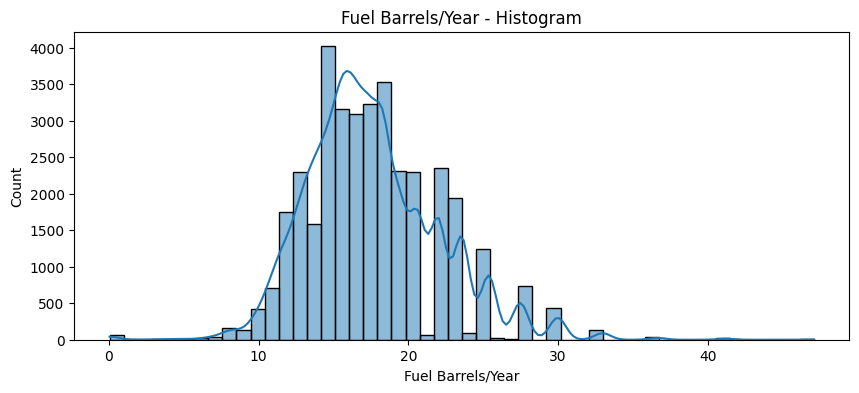

,Fuel Barrels/Year
count,35952.000000
mean,17.609056
std,4.467283
min,0.060000
25%,14.699423
50%,17.347895
75%,20.600625
max,47.087143


In [18]:
col1 = "Fuel Barrels/Year"
x = vehicles[col1].dropna()

plt.figure(figsize=(10,4))
sns.histplot(x, bins=50, kde=True)
plt.title(f"{col1} - Histogram")
plt.show()

x.describe()


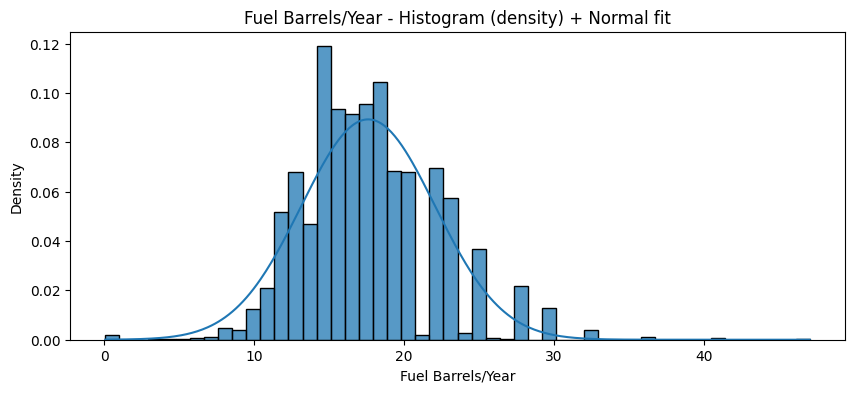

(np.float64(17.609055502328133), 4.467282686296995)

In [19]:
mu1, sigma1 = x.mean(), x.std(ddof=1)
xs = np.linspace(x.min(), x.max(), 400)

plt.figure(figsize=(10,4))
sns.histplot(x, bins=50, stat="density")
plt.plot(xs, norm.pdf(xs, loc=mu1, scale=sigma1))
plt.title(f"{col1} - Histogram (density) + Normal fit")
plt.show()

(mu1, sigma1)


2. CO2 Emission Grams/Mile

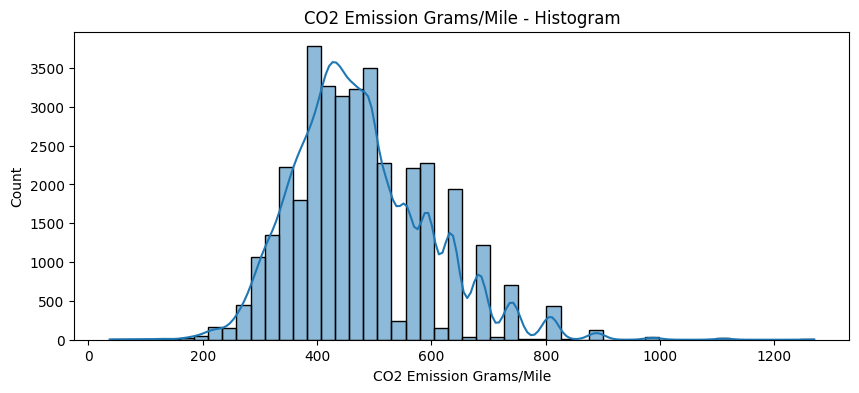

,CO2 Emission Grams/Mile
count,35952.000000
mean,475.316339
std,119.060773
min,37.000000
25%,395.000000
50%,467.736842
75%,555.437500
max,1269.571429


In [20]:
col2 = "CO2 Emission Grams/Mile"
y = vehicles[col2].dropna()

plt.figure(figsize=(10,4))
sns.histplot(y, bins=50, kde=True)
plt.title(f"{col2} - Histogram")
plt.show()

y.describe()


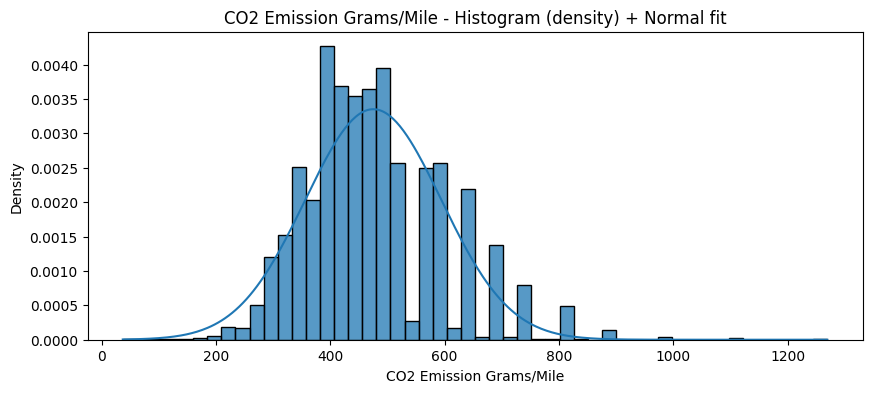

(np.float64(475.3163392572124), 119.06077323591474)

In [21]:
mu2, sigma2 = y.mean(), y.std(ddof=1)
ys = np.linspace(y.min(), y.max(), 400)

plt.figure(figsize=(10,4))
sns.histplot(y, bins=50, stat="density")
plt.plot(ys, norm.pdf(ys, loc=mu2, scale=sigma2))
plt.title(f"{col2} - Histogram (density) + Normal fit")
plt.show()

(mu2, sigma2)


3. Combined MPG

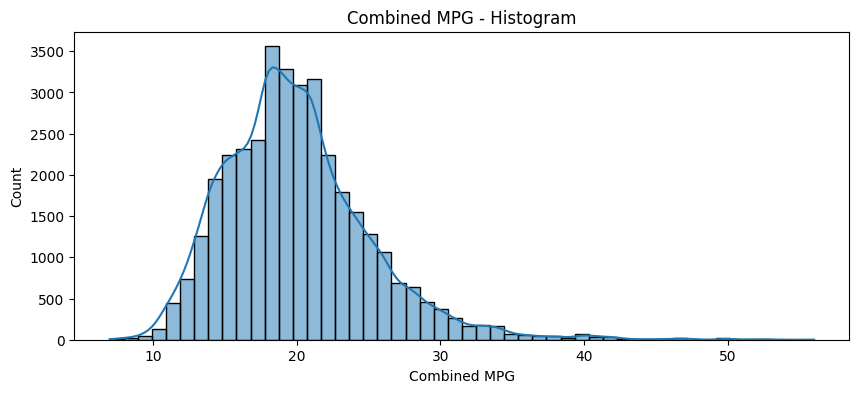

,Combined MPG
count,35952.000000
mean,19.929322
std,5.112409
min,7.000000
25%,16.000000
50%,19.000000
75%,23.000000
max,56.000000


In [22]:
col3 = "Combined MPG"
z = vehicles[col3].dropna()

plt.figure(figsize=(10,4))
sns.histplot(z, bins=50, kde=True)
plt.title(f"{col3} - Histogram")
plt.show()

z.describe()


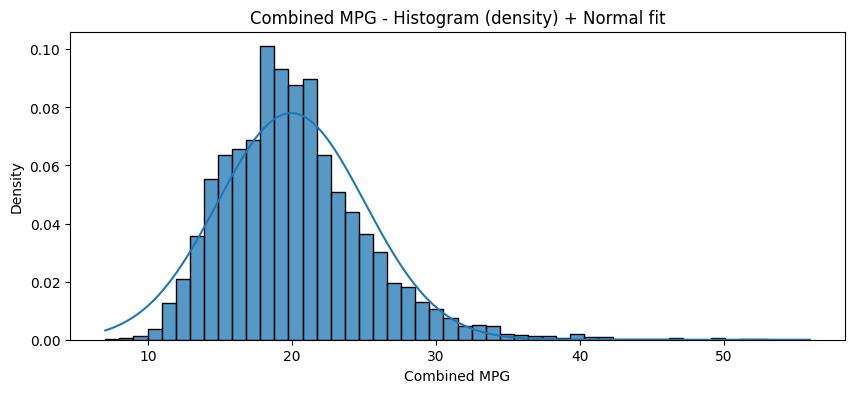

(np.float64(19.92932242990654), 5.112408944666006)

In [23]:
mu3, sigma3 = z.mean(), z.std(ddof=1)
zs = np.linspace(z.min(), z.max(), 400)

plt.figure(figsize=(10,4))
sns.histplot(z, bins=50, stat="density")
plt.plot(zs, norm.pdf(zs, loc=mu3, scale=sigma3))
plt.title(f"{col3} - Histogram (density) + Normal fit")
plt.show()

(mu3, sigma3)


In [24]:
def skewness(a: pd.Series) -> float:
    a = a.dropna()
    m = a.mean()
    s = a.std(ddof=1)
    return float(((a - m) ** 3).mean() / (s ** 3))

def excess_kurtosis(a: pd.Series) -> float:
    a = a.dropna()
    m = a.mean()
    s = a.std(ddof=1)
    return float(((a - m) ** 4).mean() / (s ** 4) - 3)

summary = pd.DataFrame({
    "variable": [col1, col2, col3],
    "mean": [mu1, mu2, mu3],
    "std": [sigma1, sigma2, sigma3],
    "skewness": [skewness(x), skewness(y), skewness(z)],
    "excess_kurtosis": [excess_kurtosis(x), excess_kurtosis(y), excess_kurtosis(z)]
})
summary


,variable,mean,std,skewness,excess_kurtosis
0,Fuel Barrels/Year,17.609056,4.467283,0.638218,1.467665
1,CO2 Emission Grams/Mile,475.316339,119.060773,0.741630,1.263003
2,Combined MPG,19.929322,5.112409,1.067684,2.721688


Which one(s) of the variables are nearly normally distributed? How do you know?

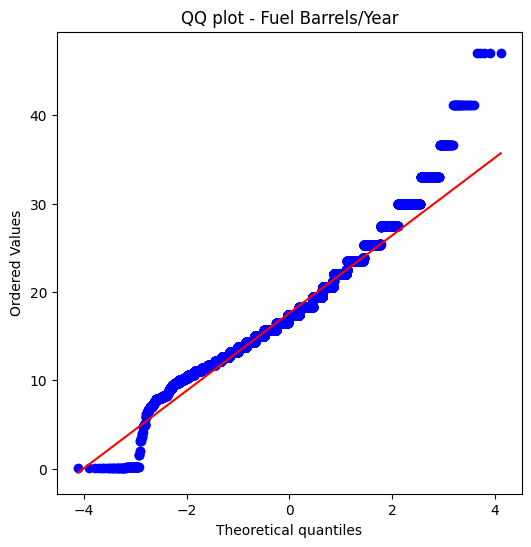

In [25]:
import scipy.stats as stats

def qq_plot(series: pd.Series, title: str):
    series = series.dropna()
    plt.figure(figsize=(6,6))
    stats.probplot(series, dist="norm", plot=plt)
    plt.title(title)
    plt.show()

qq_plot(x, f"QQ plot - {col1}")


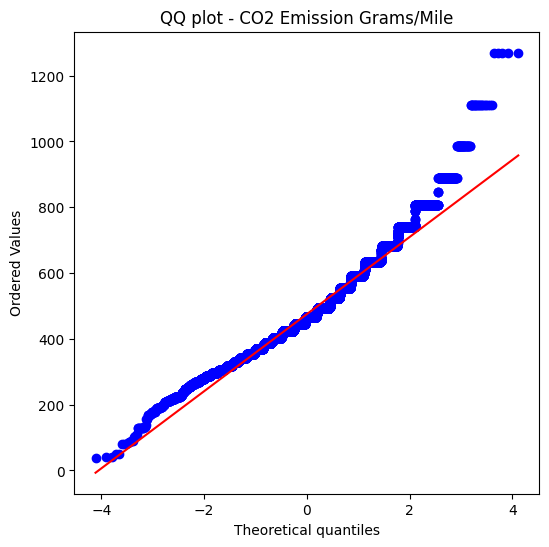

In [26]:
qq_plot(y, f"QQ plot - {col2}")


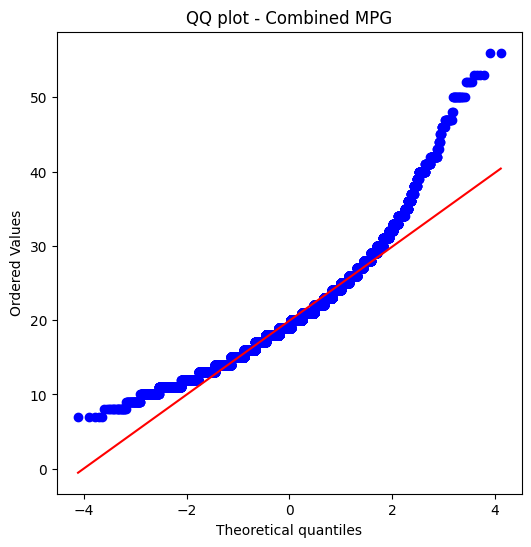

In [27]:
qq_plot(z, f"QQ plot - {col3}")


In [28]:
print(
"""Based on the histograms + normal overlays and the QQ plots:
- None of the variables look perfectly normal (there is skew / heavy tails).
- 'Combined MPG' tends to be the closest to normal (more symmetric and QQ plot is closer to a straight line),
  while the other variables show stronger skewness."""
)


Based on the histograms + normal overlays and the QQ plots:
- None of the variables look perfectly normal (there is skew / heavy tails).
- 'Combined MPG' tends to be the closest to normal (more symmetric and QQ plot is closer to a straight line),
  while the other variables show stronger skewness.


None of them are normally ditributed.

## Exponential Distribution

1. Using `numpy.random.exponential`, create a function that returns a list of numbers exponentially distributed with the mean of 10.

1. Use the function to generate two number sequences with the size of 10 and 100.

1. Plot the distributions as histograms with the nubmer of bins as 100.

Your output should look like below:

![exponential distribution](ed.png)

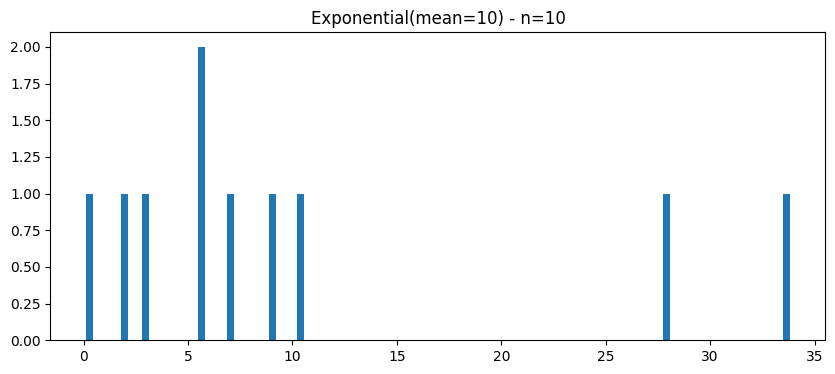

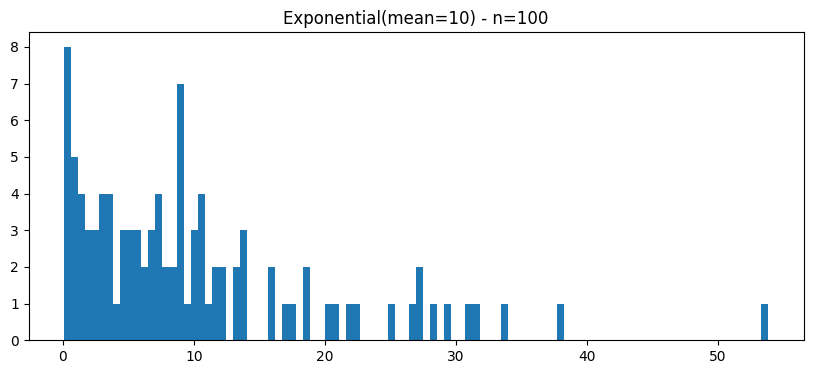

In [29]:
def generate_exponential(mean: float, count: int, seed: int | None = None) -> np.ndarray:
    """Generate exponentially distributed samples with the given mean."""
    if mean <= 0:
        raise ValueError("`mean` must be positive.")
    if count <= 0:
        raise ValueError("`count` must be a positive integer.")
    rng = np.random.default_rng(seed)
    # numpy parameterization: scale = mean
    return rng.exponential(scale=mean, size=count)

e10 = generate_exponential(mean=10, count=10, seed=7)
e100 = generate_exponential(mean=10, count=100, seed=7)

plt.figure(figsize=(10,4))
plt.hist(e10, bins=100)
plt.title("Exponential(mean=10) - n=10")
plt.show()

plt.figure(figsize=(10,4))
plt.hist(e100, bins=100)
plt.title("Exponential(mean=10) - n=100")
plt.show()


How are the two distributions different?

The mean changes, so the distribution changes as well.

## Exponential Distribution of Real Data

Suppose that the amount of time one spends in a bank is exponentially distributed with mean as 10 minutes (i.e. λ = 1/10). What is the probability that a customer will spend less than fifteen minutes in the bank?

Write a code in python to solve this problem

In [30]:
# If X ~ Exp(lambda) with mean 10, then lambda = 1/10.
lam = 1/10
p_less_15 = 1 - math.exp(-lam * 15)
p_less_15


0.7768698398515702

In [31]:
# Hint: This is same as saying P(x < 15)
print(f"P(X < 15) for Exp(mean=10) = {p_less_15:.6f}")


P(X < 15) for Exp(mean=10) = 0.776870


What is the probability that the customer will spend more than 15 minutes

In [32]:
p_more_15 = math.exp(-lam * 15)
p_more_15


0.22313016014842982